In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

In [2]:
df_merged = pd.read_csv("Downloads/Dataset_histo_NEWS_2017_2023.csv")

In [4]:
# Drop rows with missing values
df = df_merged.dropna().copy()

In [5]:
le = LabelEncoder()
df["Newsenti"] = le.fit_transform(df["Newsenti"].astype(str))

In [7]:
df.columns = df.columns.str.strip()

# Independent variables (X)
X = df[["Index","Newscore","Newsenti"]]
# Dependent variable (y)
y = df["volatility"]

In [8]:
# Initialize model
lr = LinearRegression()

# Fit model
lr.fit(X, y)

# Predictions
y_pred = lr.predict(X)

# Residuals
df["residuals"] = y - y_pred

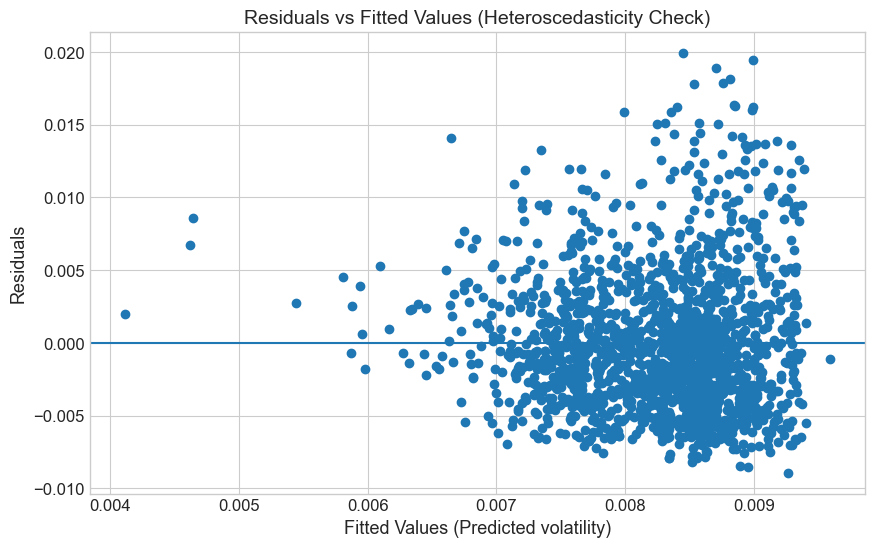

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic look

plt.rcParams.update({"font.size": 12,"figure.figsize": (10, 6),"axes.labelsize": 13,"axes.titlesize": 14,"legend.fontsize": 11})
plt.figure()
plt.scatter(y_pred, df["residuals"])
plt.axhline(0)
plt.xlabel("Fitted Values (Predicted volatility)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Heteroscedasticity Check)")
plt.show()

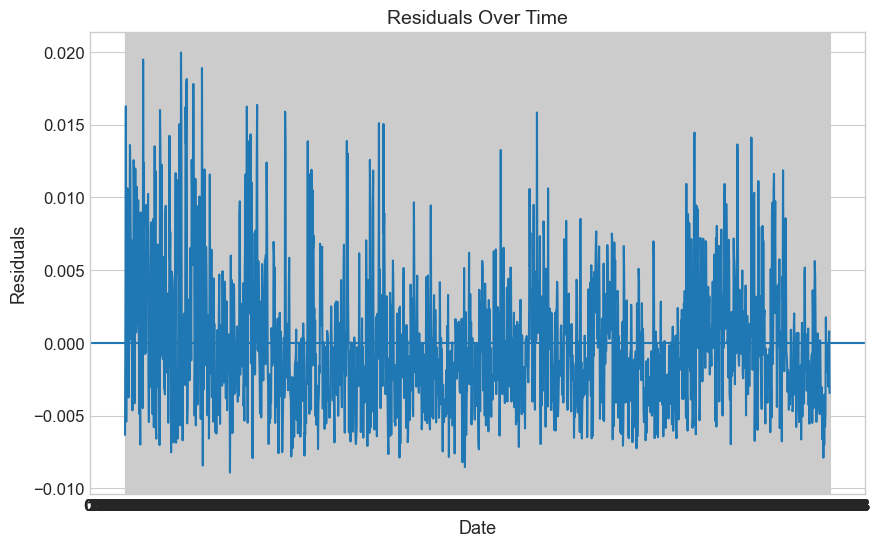

In [10]:
plt.figure()
plt.plot(df["Date"], df["residuals"])
plt.axhline(0)
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.title("Residuals Over Time")
plt.show()

In [11]:
# Add constant for statsmodels
X_sm = sm.add_constant(X)

# Fit OLS model
ols_model = sm.OLS(y, X_sm).fit()

# Breusch-Pagan test
bp_test = het_breuschpagan(ols_model.resid, X_sm)

bp_results = {"LM Statistic": bp_test[0],"LM p-value": bp_test[1],"F Statistic": bp_test[2],"F p-value": bp_test[3]}
print(bp_results)

{'LM Statistic': 30.970712519616985, 'LM p-value': 8.622040280189002e-07, 'F Statistic': 10.48910544938864, 'F p-value': 7.751496473946165e-07}
